In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [66]:
# Set plot style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [67]:
# Data Loading, Cleaning, and Preprocessing
df = pd.read_csv('regression_training_dataset.csv') 
print(f'Dataset shape: {df.shape}')
print(df.isnull().sum())

Dataset shape: (200, 5)
StudyHoursPerWeek       0
AttendancePercent       0
AssignmentsCompleted    0
ExperienceYears         0
PerformanceScore        0
dtype: int64


In [68]:
X = df.drop(columns="PerformanceScore")
y = df["PerformanceScore"]

In [69]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
# feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
# Convert scaled arrays back to DataFrames for VIF calculation later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled_df

,StudyHoursPerWeek,AttendancePercent,AssignmentsCompleted,ExperienceYears
0,1.203760,0.927674,-1.194514,0.927239
1,-0.543986,0.589377,0.460224,0.321695
2,-1.243084,-1.440405,-1.690936,-1.192164
3,1.203760,-1.778702,1.287593,-1.494936
4,-0.893535,0.166506,0.460224,-1.494936
...,...,...,...,...
155,-0.893535,1.265971,0.625698,-1.192164
156,0.155112,-0.256366,-0.698093,-0.586621
157,-0.194437,0.927674,0.791172,0.018923
158,0.155112,0.504803,-0.863566,0.927239


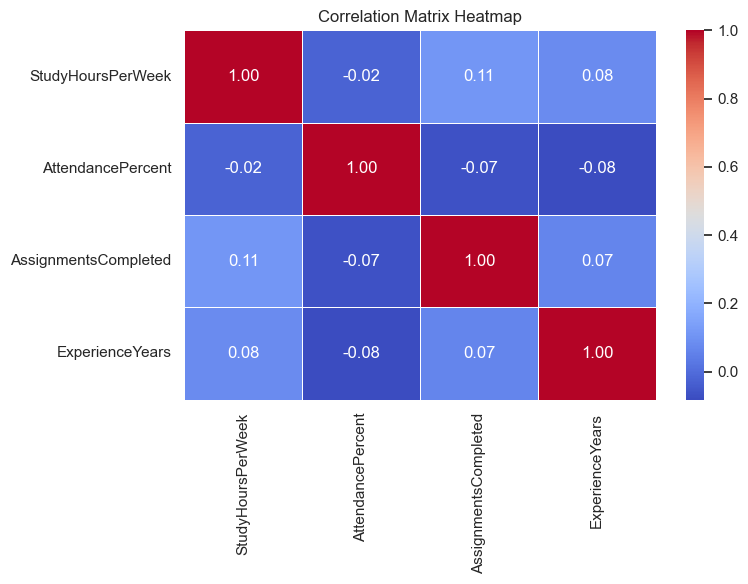

In [72]:
# Correaltion Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X_train_scaled_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png')
plt.show()
plt.close()

C:\Users\MSI\AppData\Local\Temp\ipykernel_17436\1702319148.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


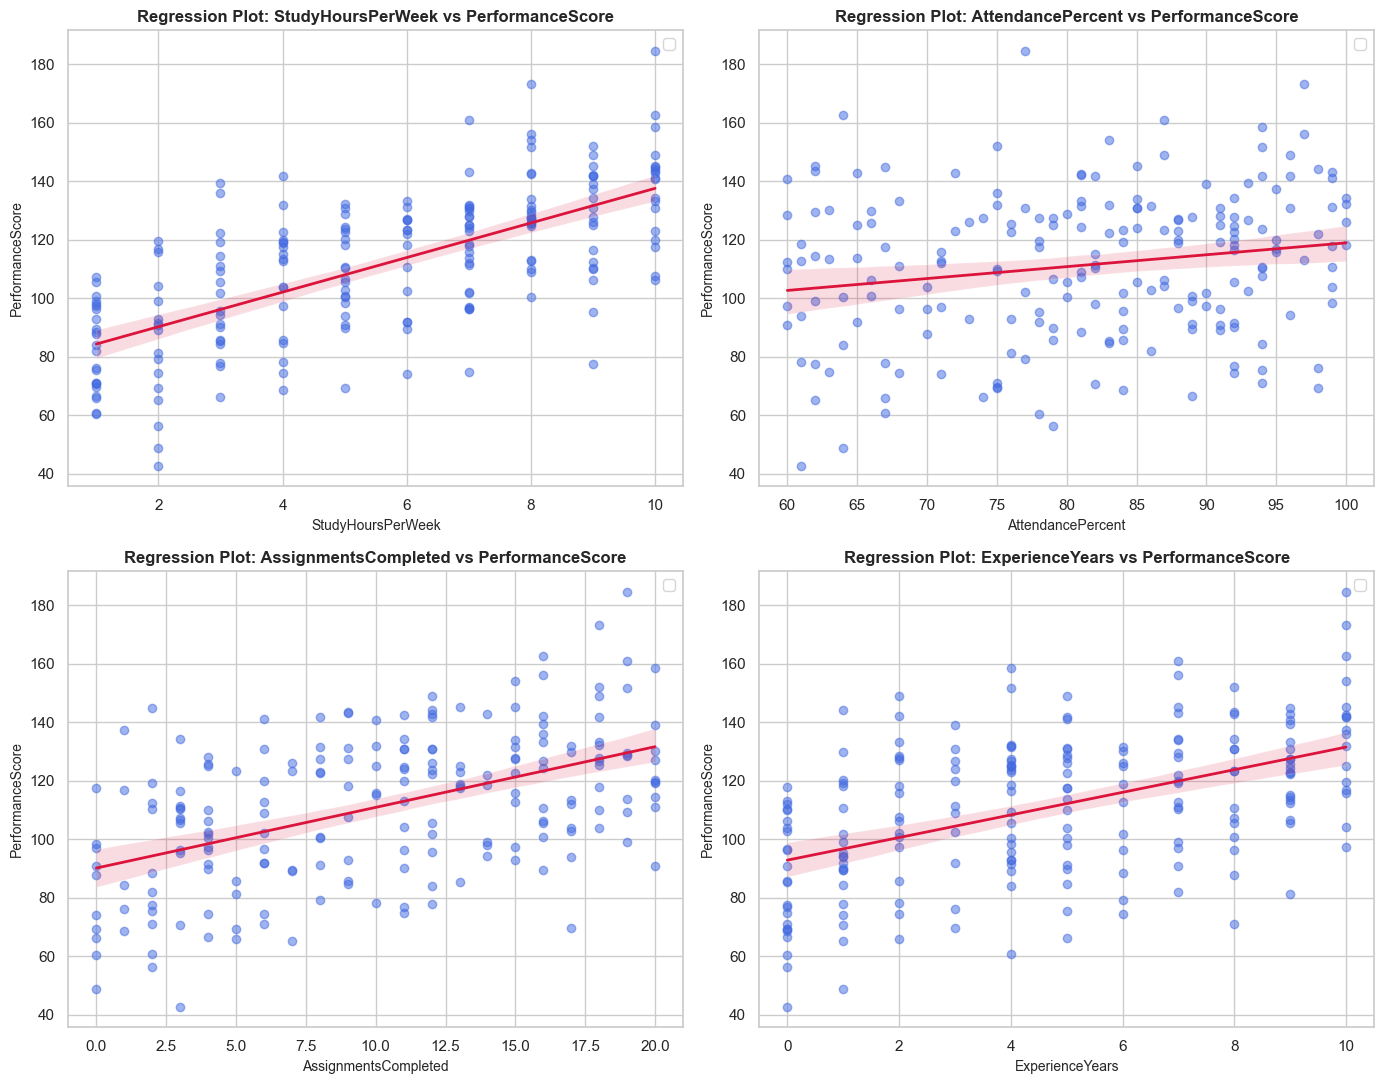

EDA plots saved as 'eda_features_vs_target_best_fit.png'.


In [73]:
fig,axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.regplot(
        x = df[col],
        y = df['PerformanceScore'],
        ax = axes[i],
        scatter_kws={'alpha':0.5, 'color':'royalblue'},
        line_kws={'color':'crimson', 'linewidth':2}
    )
    axes[i].set_title(f'Regression Plot: {col} vs PerformanceScore', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('PerformanceScore', fontsize=10)
    axes[i].legend()
    
plt.tight_layout()
plt.savefig('eda_features_vs_target_best_fit.png')
plt.show()
plt.close()
print("EDA plots saved as 'eda_features_vs_target_best_fit.png'.")

In [74]:
# Helper Evaluation Function
models_report = {}
trained_models = {}

def evaluate_model(model, name, X_tr, X_te, y_tr, y_te):
    # predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Calculate metrics
    metrics = {
        'Train RMSE': np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'Train MAE': mean_absolute_error(y_tr, y_pred_train),
        'Test MAE': mean_absolute_error(y_te, y_pred_test),
        'Train R2': r2_score(y_tr, y_pred_train),
        'Test R2': r2_score(y_te, y_pred_test)
    }
    
    models_report[name] = metrics
    trained_models[name] = model
    
    print(f"\n [{name} Performance Metrics]")
    print(f"Train R²: {metrics['Train R2']:.4f}, Test R²: {metrics['Test R2']:.4f}")
    print(f"Train RMSE: {metrics['Train RMSE']:.4f}, Test RMSE: {metrics['Test RMSE']:.4f}")
    return metrics

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
evaluate_model(lr_model, "Linear Regression", X_train_scaled, X_test_scaled, y_train, y_test)


 [Linear Regression Performance Metrics]
Train R²: 0.8877, Test R²: 0.8985
Train RMSE: 8.2721, Test RMSE: 8.5239


{'Train RMSE': np.float64(8.272081342859593),
 'Test RMSE': np.float64(8.523864321618145),
 'Train MAE': 6.4390001682484925,
 'Test MAE': 6.8035885180645534,
 'Train R2': 0.8877433196170723,
 'Test R2': 0.8985064262772665}

In [76]:
# check multicollinearity using VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled_df.values, i) for i in range(len(X.columns))]
print("\nVariance Inflation Factor (VIF) for each feature:")
print(vif_data)


Variance Inflation Factor (VIF) for each feature:
                feature       VIF
0     StudyHoursPerWeek  1.018685
1     AttendancePercent  1.010818
2  AssignmentsCompleted  1.019966
3       ExperienceYears  1.016077


In [77]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
evaluate_model(ridge_model, "Ridge Regression", X_train_scaled, X_test_scaled, y_train, y_test)


 [Ridge Regression Performance Metrics]
Train R²: 0.8877, Test R²: 0.8978
Train RMSE: 8.2731, Test RMSE: 8.5527


{'Train RMSE': np.float64(8.273140215453887),
 'Test RMSE': np.float64(8.552706332399918),
 'Train MAE': 6.439734409771981,
 'Test MAE': 6.837111190783153,
 'Train R2': 0.8877145788140792,
 'Test R2': 0.8978184211375639}

In [78]:
# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
evaluate_model(lasso_model, "Lasso Regression", X_train_scaled, X_test_scaled, y_train, y_test)


 [Lasso Regression Performance Metrics]
Train R²: 0.8877, Test R²: 0.8976
Train RMSE: 8.2744, Test RMSE: 8.5610


{'Train RMSE': np.float64(8.274432208596716),
 'Test RMSE': np.float64(8.560961656447182),
 'Train MAE': 6.440349743806662,
 'Test MAE': 6.855434165060426,
 'Train R2': 0.887679505475981,
 'Test R2': 0.8976210685995055}

In [79]:
# Elastic Net Regression
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_model.fit(X_train_scaled, y_train)
evaluate_model(elastic_model, "Elastic Net Regression", X_train_scaled, X_test_scaled, y_train, y_test)


 [Elastic Net Regression Performance Metrics]
Train R²: 0.8857, Test R²: 0.8912
Train RMSE: 8.3460, Test RMSE: 8.8239


{'Train RMSE': np.float64(8.346027351959808),
 'Test RMSE': np.float64(8.823871119340618),
 'Train MAE': 6.49028176956155,
 'Test MAE': 7.12744351622794,
 'Train R2': 0.8857273734177694,
 'Test R2': 0.891236343192998}

In [80]:
print("\n--- Comparing Performance Matrix ---")
df_comparison = pd.DataFrame(models_report).T
print(df_comparison[['Train R2', 'Test R2', 'Train RMSE', 'Test RMSE']])


--- Comparing Performance Matrix ---
                        Train R2   Test R2  Train RMSE  Test RMSE
Linear Regression       0.887743  0.898506    8.272081   8.523864
Ridge Regression        0.887715  0.897818    8.273140   8.552706
Lasso Regression        0.887680  0.897621    8.274432   8.560962
Elastic Net Regression  0.885727  0.891236    8.346027   8.823871


In [81]:
# Visualizing Overfitting and Underfitting chart

# Reshaping data for visualization
plot_data = []
for model_name, metrics in models_report.items():
    plot_data.append({
        'Model': model_name,
        'Dataset': "Train",
        'R2': metrics['Train R2'],
        'RMSE': metrics['Train RMSE'],
    })
    plot_data.append({
        'Model': model_name,
        'Dataset': "Test",
        'R2': metrics['Test R2'],
        'RMSE': metrics['Test RMSE'],
    })
    df_plot = pd.DataFrame(plot_data)

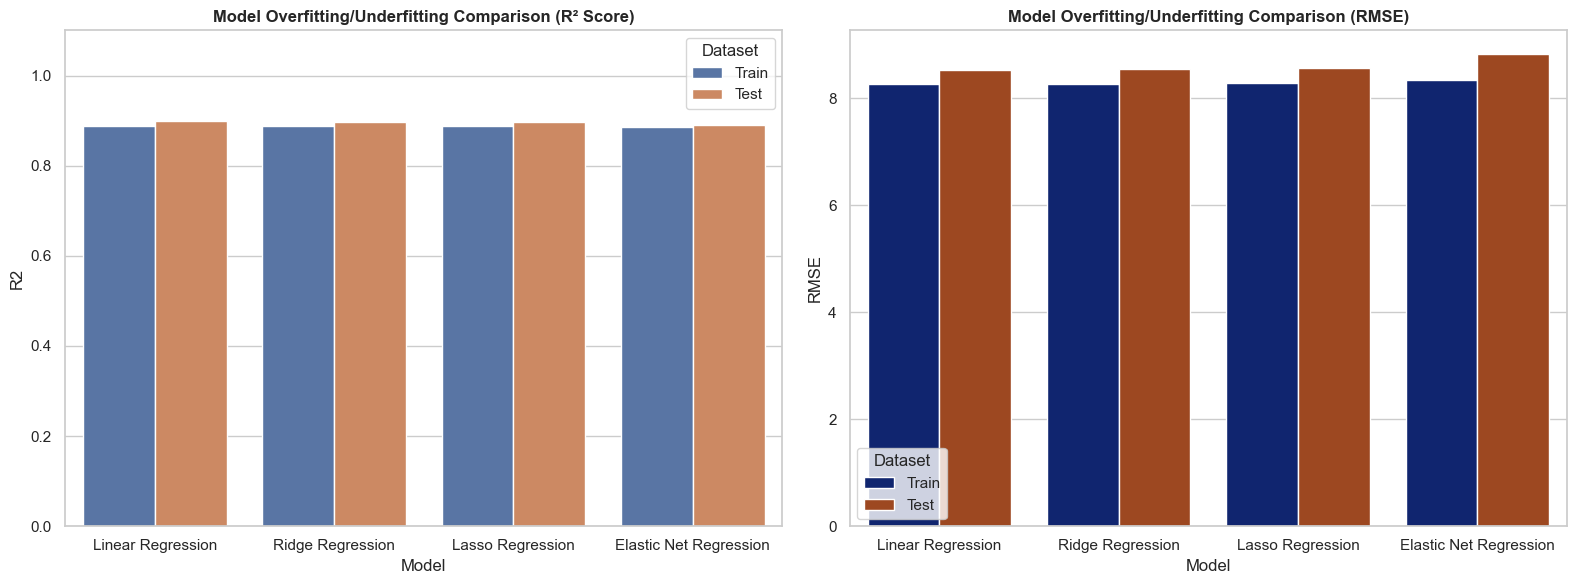

Overfitting/Underfitting comparison plots saved as 'model_overfitting_underfitting_comparison.png'.


In [82]:
# Generating Comparision Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score Comparison
sns.barplot(x='Model', y='R2', hue='Dataset', data=df_plot, ax=axes[0])
axes[0].set_title('Model Overfitting/Underfitting Comparison (R² Score)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.1)

for p in axes[0].patches:
    h = p.get_height()
    
    if h > 0:
        axes[0].annotate(f'{h:.3f}', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, color='white', fontweight='bold')
        
# RMSE Comparison
sns.barplot(x='Model', y='RMSE', hue='Dataset', data=df_plot, ax=axes[1], palette='dark')
axes[1].set_title('Model Overfitting/Underfitting Comparison (RMSE)', fontsize=12, fontweight='bold')

for p in axes[1].patches:
    h = p.get_height()
    
    if h > 0:
        axes[1].annotate(f'{h:.3f}', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('model_overfitting_underfitting_comparison.png')
plt.show()
plt.close()
print("Overfitting/Underfitting comparison plots saved as 'model_overfitting_underfitting_comparison.png'.")

In [83]:
# Choose Best Model & plot its best fit line

best_model_name = df_comparison['Test R2'].idxmax()
best_model = trained_models[best_model_name]
print(f"\n -- Conclusion ---")
print(f"Best Model: {best_model_name}")
print(f"Best Model R2 Score: {df_comparison.loc[best_model_name, 'Test R2']:.3f}")


 -- Conclusion ---
Best Model: Linear Regression
Best Model R2 Score: 0.899


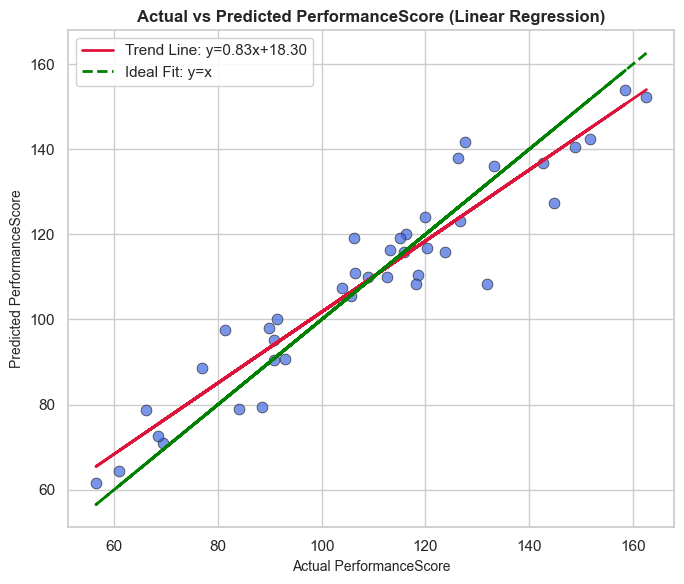

Best model actual vs predicted plot saved as 'best_model_actual_vs_predicted_linear_regression.png'.


In [84]:
#Generating Final Prediction Fit plots
y_pred_best = best_model.predict(X_test_scaled)
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_best, ax=ax, color='royalblue', alpha=0.7, edgecolor='k', s=60)

# Generate trend line coefficients for predictions
m, b = np.polyfit(y_test, y_pred_best, 1)
ax.plot(y_test, m*y_test + b, color='crimson', linewidth=2, label=f'Trend Line: y={m:.2f}x+{b:.2f}')

# Reference baseline for ideal 1:1 parity prediction
ax.plot(y_test, y_test, color='green', linestyle='--', linewidth=2, label='Ideal Fit: y=x')

ax.set_title(f"Actual vs Predicted PerformanceScore ({best_model_name})", fontsize=12, fontweight='bold')
ax.set_xlabel("Actual PerformanceScore", fontsize=10)
ax.set_ylabel("Predicted PerformanceScore", fontsize=10)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'best_model_actual_vs_predicted_{best_model_name.replace(" ", "_").lower()}.png')
plt.show()
plt.close()
print(f"Best model actual vs predicted plot saved as 'best_model_actual_vs_predicted_{best_model_name.replace(' ', '_').lower()}.png'.")
